In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = sns.load_dataset('tips')

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.shape

(244, 7)

In [5]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [6]:
X = df[['total_bill', 'size']]
y = df['tip']

In [7]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()

In [9]:
X_train = scaler.fit_transform(X_train)

In [10]:
X_test = scaler.transform(X_test)

In [11]:
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

In [12]:
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

C:\Users\Acer\AppData\Local\Temp\ipykernel_13308\341643106.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)


In [13]:
class TipPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        
    def forward(self, x):
        return self.network(x)

In [14]:
model = TipPredictor()
model

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [15]:
criterion = nn.MSELoss()

In [16]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [17]:
epochs = 300

loss_history = []

for epoch in range(epochs):
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if (epoch+1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [25/300], Loss: 1.7818
Epoch [50/300], Loss: 1.3089
Epoch [75/300], Loss: 1.1662
Epoch [100/300], Loss: 1.0993
Epoch [125/300], Loss: 1.0750
Epoch [150/300], Loss: 1.0626
Epoch [175/300], Loss: 1.0521
Epoch [200/300], Loss: 1.0442
Epoch [225/300], Loss: 1.0366
Epoch [250/300], Loss: 1.0297
Epoch [275/300], Loss: 1.0248
Epoch [300/300], Loss: 1.0215


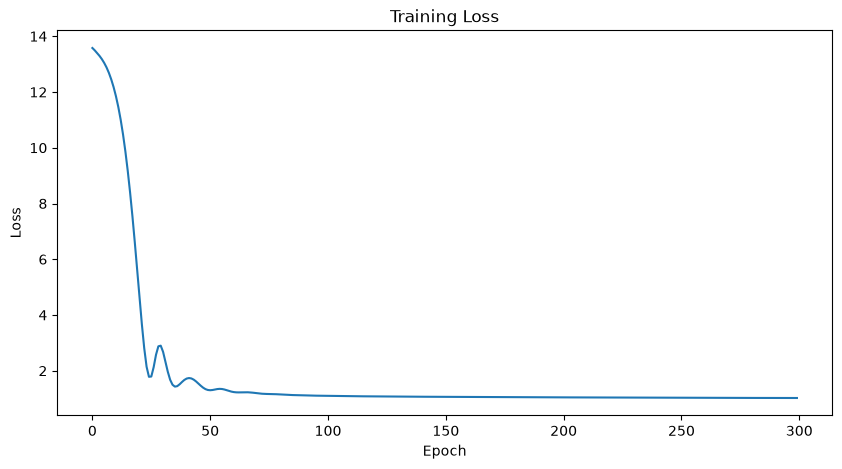

In [18]:
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [19]:
model.eval()

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [20]:
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred = y_pred.numpy()
    y_real = y_test_tensor.numpy()
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    print('Model Performance:')
    print("-" * 35)
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

Model Performance:
-----------------------------------
MAE: 0.6702
MSE: 0.7278
RMSE: 0.8531
R²: 0.4178


In [21]:
results = pd.DataFrame({
    'Actual Tip' : y_real.flatten(),
    'Predicted Tip' : y_pred.flatten()
})

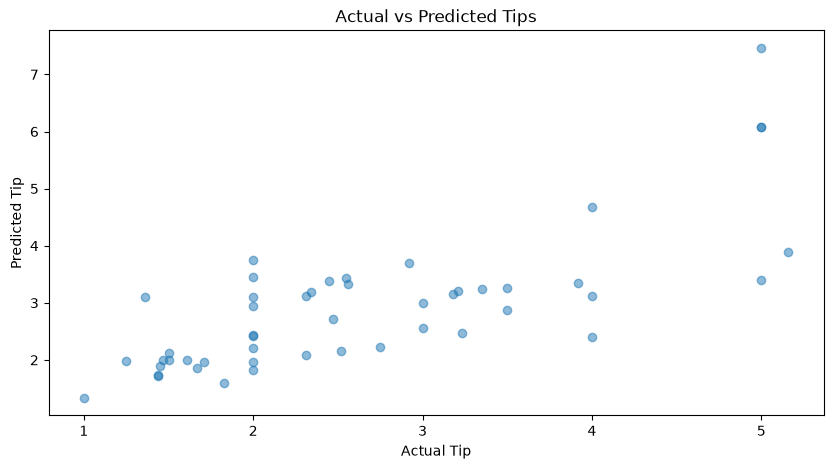

In [22]:
plt.figure(figsize=(10, 5))
plt.scatter(y_real, y_pred, alpha=0.5)
plt.xlabel('Actual Tip')
plt.ylabel('Predicted Tip')
plt.title('Actual vs Predicted Tips')
plt.show()

In [23]:
new_customer = np.array([[25.5, 2]])
new_customer = scaler.transform(new_customer)

c:\Users\Acer\Study_work Material\ML-Course-\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
new_customer_tensor = torch.FloatTensor(new_customer)

In [25]:
model.eval()

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [26]:
with torch.no_grad():
    predicted_tip = model(new_customer_tensor)
    print(f"$ {predicted_tip.item():.2f} is the predicted tip for a total bill of $25.50 and a party size of 2.")

$ 3.39 is the predicted tip for a total bill of $25.50 and a party size of 2.


In [27]:
from sklearn.datasets import load_iris

In [28]:
iris = load_iris()

In [29]:
X = iris.data

In [30]:
y = iris.target

In [31]:
print('Feature Shape: ', X.shape)

Feature Shape:  (150, 4)


In [32]:
print('Target Shape: ', y.shape)

Target Shape:  (150,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
scaler = StandardScaler()

In [35]:
X_train = scaler.fit_transform(X_train)

In [36]:
X_test = scaler.transform(X_test)

In [37]:
X_train_tensor = torch.FloatTensor(X_train)

In [38]:
X_test_tensor = torch.FloatTensor(X_test)

In [39]:
y_train_tensor = torch.LongTensor(y_train)

In [40]:
y_test_tensor = torch.LongTensor(y_test)

In [41]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
        
    def forward(self, x):
        return self.network(x)

In [42]:
model = IrisClassifier()

In [43]:
model

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [44]:
criterion = nn.CrossEntropyLoss()

In [45]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [46]:
epochs = 300

loss_history = []
for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [20/300], Loss: 0.3820
Epoch [40/300], Loss: 0.1305
Epoch [60/300], Loss: 0.0443
Epoch [80/300], Loss: 0.0339
Epoch [100/300], Loss: 0.0299
Epoch [120/300], Loss: 0.0261
Epoch [140/300], Loss: 0.0214
Epoch [160/300], Loss: 0.0155


Epoch [180/300], Loss: 0.0093
Epoch [200/300], Loss: 0.0052
Epoch [220/300], Loss: 0.0032
Epoch [240/300], Loss: 0.0022
Epoch [260/300], Loss: 0.0016
Epoch [280/300], Loss: 0.0012
Epoch [300/300], Loss: 0.0009


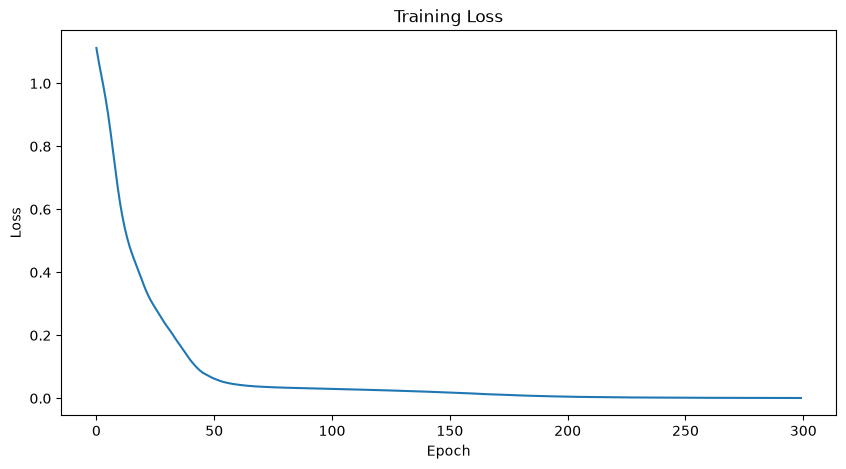

In [47]:
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [48]:
model.eval()

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [50]:
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predictions = torch.max(outputs, 1)
    accuracy = accuracy_score(y_test_tensor.numpy(), predictions.numpy())
    print(f'Test Accuracy: {accuracy:.4f}')
    cm = confusion_matrix(y_test_tensor.numpy(), predictions.numpy())
    print('Confusion Matrix:')
    print(cm)

Test Accuracy: 0.9667
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


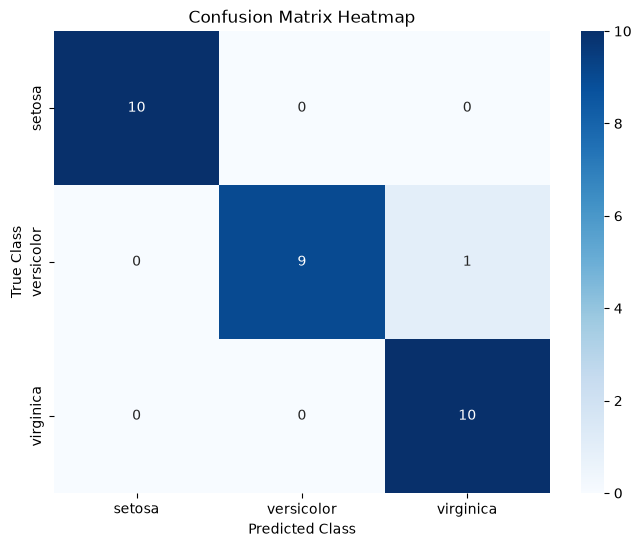

In [51]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [52]:
print('Classification Report:')
print(classification_report(y_test_tensor.numpy(), predictions.numpy(), target_names=iris.target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [53]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
sample = scaler.transform(sample)
sample_tensor = torch.FloatTensor(sample)

In [54]:
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output, dim=1).item()
    print("Predicted Flower: ", iris.target_names[predicted_class])

Predicted Flower:  setosa
